# Titanic Survival Prediction - Exploratory Data Analysis & Preprocessing Strategy

This notebook contains the complete **Phase 1** analysis of the Titanic dataset. 
We will perform:
1. **Dataset Inspection**: Shape, data types, missing values, duplicate rows, target distribution.
2. **Exploratory Data Analysis (EDA)**: Visualizations of distributions, correlations, outliers, and survival relationship with features.
3. **Preprocessing Decisions**: Columns to drop, encode, impute, feature engineering, and scaling justification.

## 1. Setup and Loading the Dataset
First, we import the required libraries and add the root directory to the path so we can import our preprocessing utilities from `utils/preprocess.py`.

In [1]:
import sys
import os
# Add root folder to python path
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.preprocess import (
    load_dataset,
    split_features_target,
    detect_feature_types,
    clean_dataset,
    engineer_features,
    encode_features,
    prepare_train_test_split
)

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Detect and load dataset
dataset_path = '../dataset/train_and_test2.csv'
df = load_dataset(dataset_path)
print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (1309, 28)


## 2. Dataset Inspection

In [2]:
print("--- Column Names & Data Types ---")
print(df.dtypes)

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values in raw dataset!")

print("\n--- Duplicate Rows ---")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n--- Basic Statistics ---")
display(df.describe())

--- Column Names & Data Types ---
Passengerid      int64
Age            float64
Fare           float64
Sex              int64
sibsp            int64
zero             int64
zero.1           int64
zero.2           int64
zero.3           int64
zero.4           int64
zero.5           int64
zero.6           int64
Parch            int64
zero.7           int64
zero.8           int64
zero.9           int64
zero.10          int64
zero.11          int64
zero.12          int64
zero.13          int64
zero.14          int64
Pclass           int64
zero.15          int64
zero.16          int64
Embarked       float64
zero.17          int64
zero.18          int64
2urvived         int64
dtype: object

--- First 5 Rows ---


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0



--- Missing Values ---
Embarked    2
dtype: int64

--- Duplicate Rows ---
Number of duplicate rows: 0

--- Basic Statistics ---


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


### Target Column Inspection
The target column in this dataset is **`2urvived`** (representing **`Survived`**).

In [3]:
target_counts = df['2urvived'].value_counts()
target_pct = df['2urvived'].value_counts(normalize=True) * 100
for val, count in target_counts.items():
    print(f"Class {val}: {count} ({target_pct[val]:.2f}%)")

Class 0: 967 (73.87%)
Class 1: 342 (26.13%)


### Observation on Dataset Structure:
- The target column is labeled `2urvived`.
- The columns `zero`, `zero.1` ... `zero.18` contain only 0s and have no predictive power. They must be dropped.
- `Sex` is already encoded as binary (`0` for male, `1` for female).
- `Embarked` has 2 missing values. It's encoded as float categories (0.0, 1.0, 2.0).
- Columns like `Name`, `Ticket`, and `Cabin` are completely missing from this CSV. Thus, text-based feature extraction (like Title or Deck) is not possible.

## 3. Exploratory Data Analysis (EDA)

Let's clean the dataset (dropping zero columns and ID column) first so that visualizations are meaningful and clean.

In [4]:
# Drop zero columns and Passengerid for EDA
df_eda = clean_dataset(df, drop_zeros=True)
print(f"EDA DataFrame shape: {df_eda.shape}")
print("Remaining columns:", df_eda.columns.tolist())

EDA DataFrame shape: (1309, 8)
Remaining columns: ['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked', '2urvived']


### Class Distribution

C:\Users\Monii\AppData\Local\Temp\ipykernel_22488\1428263906.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='2urvived', data=df_eda, palette='viridis')


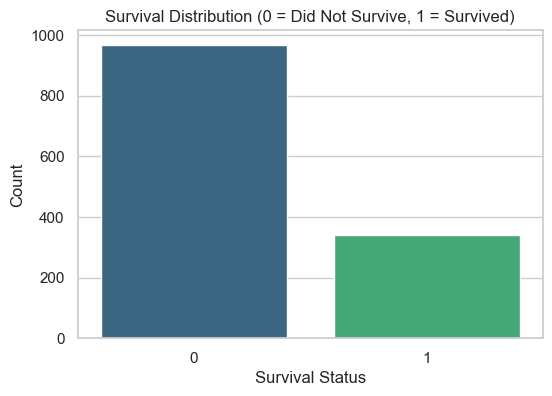

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='2urvived', data=df_eda, palette='viridis')
plt.title('Survival Distribution (0 = Did Not Survive, 1 = Survived)')
plt.xlabel('Survival Status')
plt.ylabel('Count')
plt.show()

### Correlation Heatmap

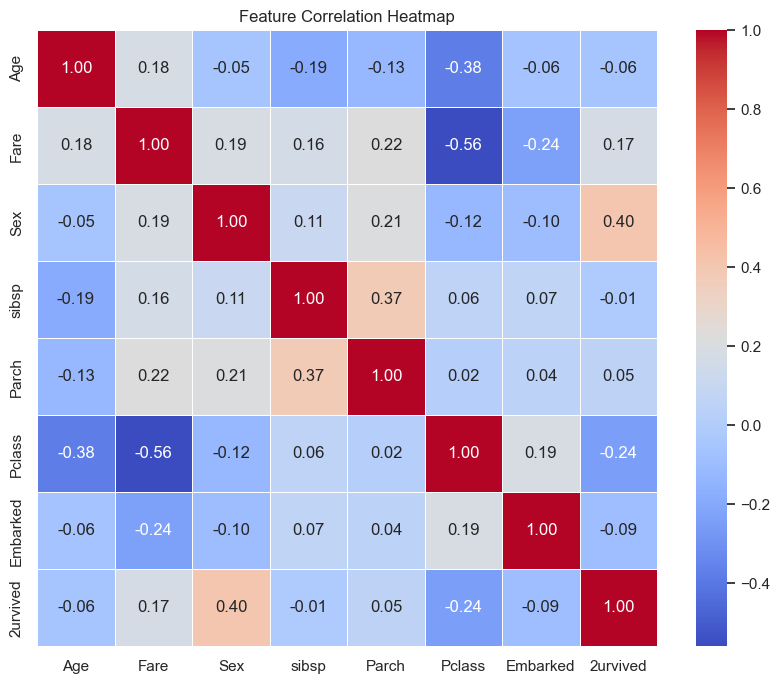

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_eda.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

### Histograms (Numerical Features: Age and Fare)

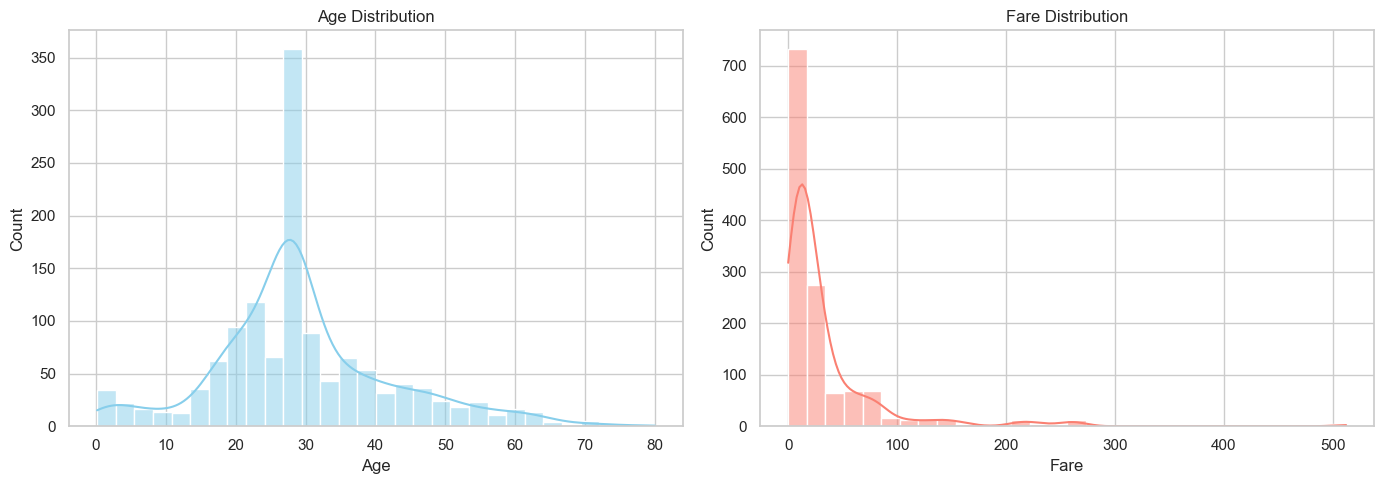

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_eda['Age'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df_eda['Fare'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Fare Distribution')

plt.tight_layout()
plt.show()

### Countplots for Categorical and Discrete Features

C:\Users\Monii\AppData\Local\Temp\ipykernel_22488\1675838912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df_eda, ax=axes[0, 0], palette='muted')
C:\Users\Monii\AppData\Local\Temp\ipykernel_22488\1675838912.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df_eda, ax=axes[0, 1], palette='muted')
C:\Users\Monii\AppData\Local\Temp\ipykernel_22488\1675838912.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Embarked', data=df_eda, ax=axes[1, 0], palette='muted')
C:\Users\Monii\AppData\Local\Tem

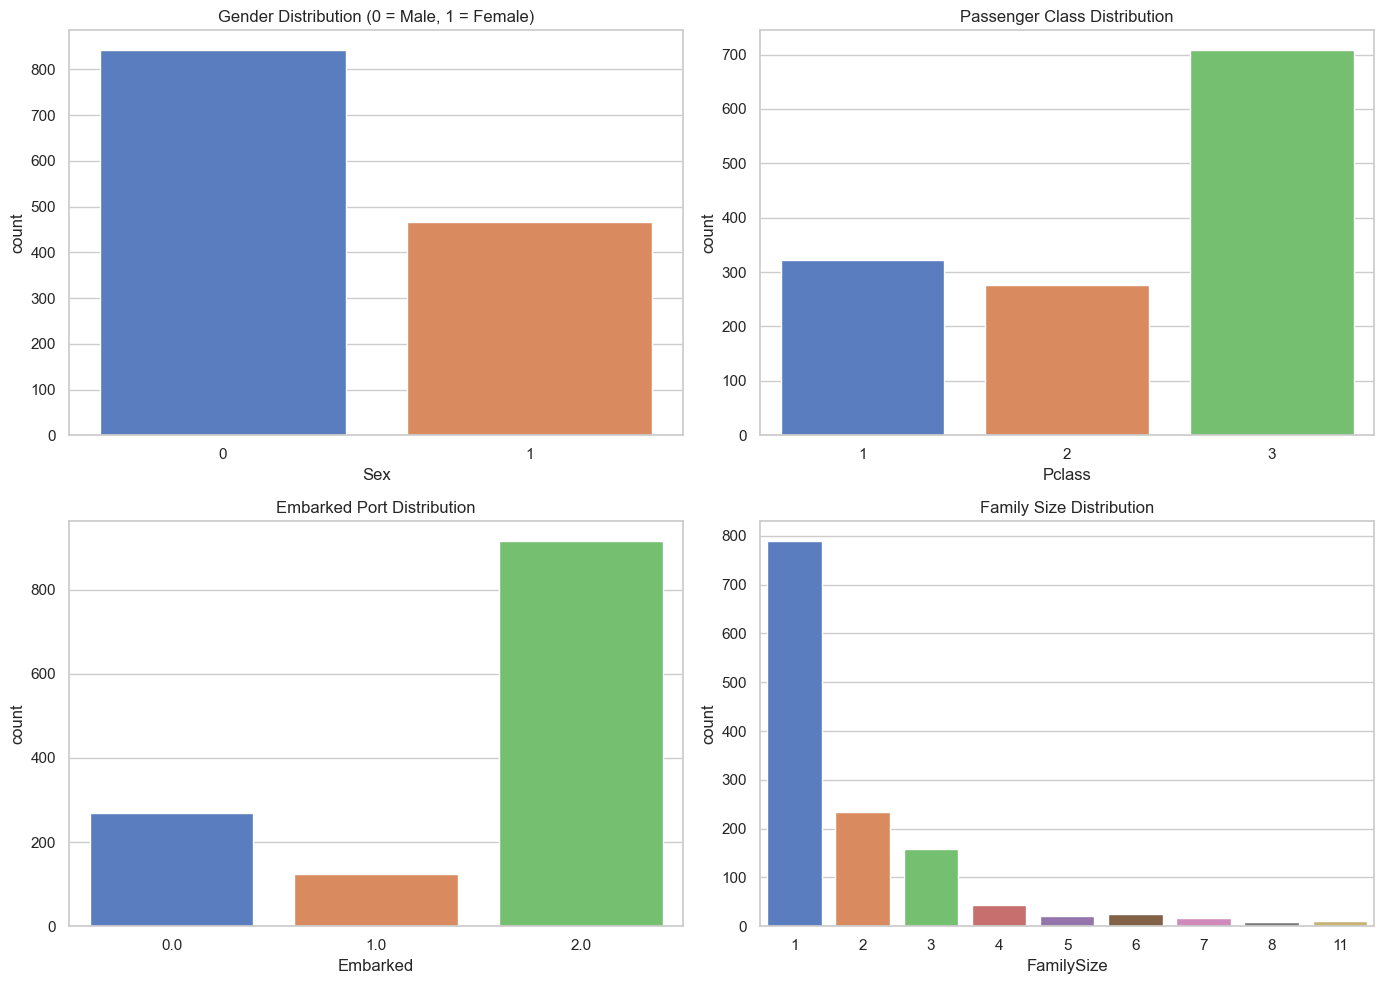

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='Sex', data=df_eda, ax=axes[0, 0], palette='muted')
axes[0, 0].set_title('Gender Distribution (0 = Male, 1 = Female)')

sns.countplot(x='Pclass', data=df_eda, ax=axes[0, 1], palette='muted')
axes[0, 1].set_title('Passenger Class Distribution')

sns.countplot(x='Embarked', data=df_eda, ax=axes[1, 0], palette='muted')
axes[1, 0].set_title('Embarked Port Distribution')

# Combine SibSp and Parch into FamilySize for countplot
df_eda_feat = engineer_features(df_eda)
sns.countplot(x='FamilySize', data=df_eda_feat, ax=axes[1, 1], palette='muted')
axes[1, 1].set_title('Family Size Distribution')

plt.tight_layout()
plt.show()

### Boxplots & Outlier Detection

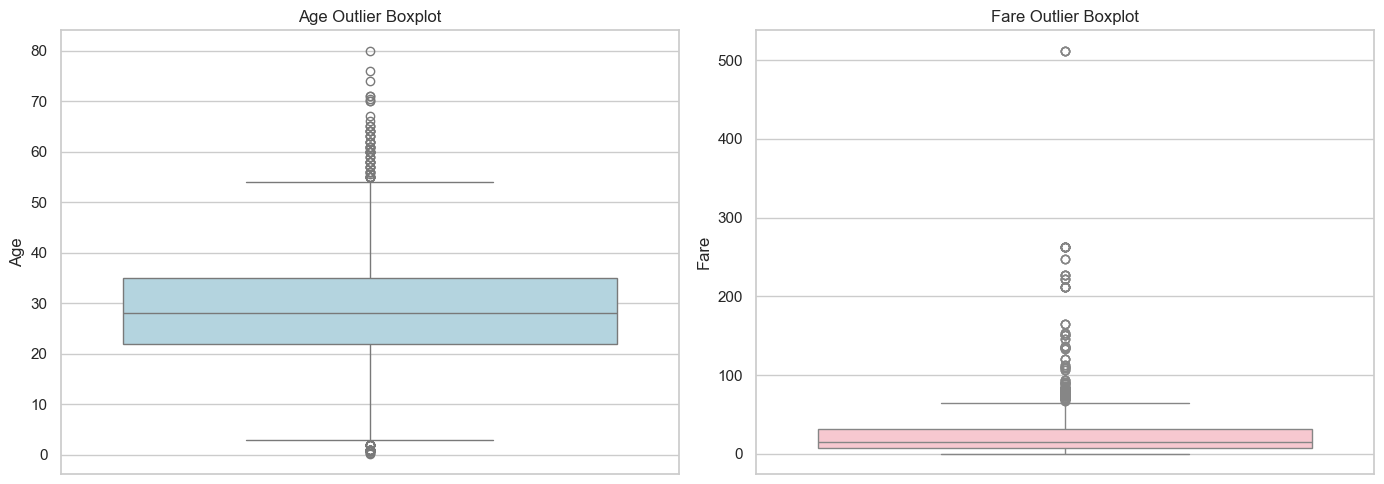

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y='Age', data=df_eda, ax=axes[0], color='lightblue')
axes[0].set_title('Age Outlier Boxplot')

sns.boxplot(y='Fare', data=df_eda, ax=axes[1], color='pink')
axes[1].set_title('Fare Outlier Boxplot')

plt.tight_layout()
plt.show()

### Survival Analysis against Features

C:\Users\Monii\AppData\Local\Temp\ipykernel_22488\795490233.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sex', y='2urvived', data=df_eda, ax=axes[0, 0], ci=None, palette='viridis')
C:\Users\Monii\AppData\Local\Temp\ipykernel_22488\795490233.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='2urvived', data=df_eda, ax=axes[0, 0], ci=None, palette='viridis')
C:\Users\Monii\AppData\Local\Temp\ipykernel_22488\795490233.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Male (0)', 'Female (1)'])
C:\Users\Monii\AppData\Local\Temp\ipykernel_22488\795490233.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effec

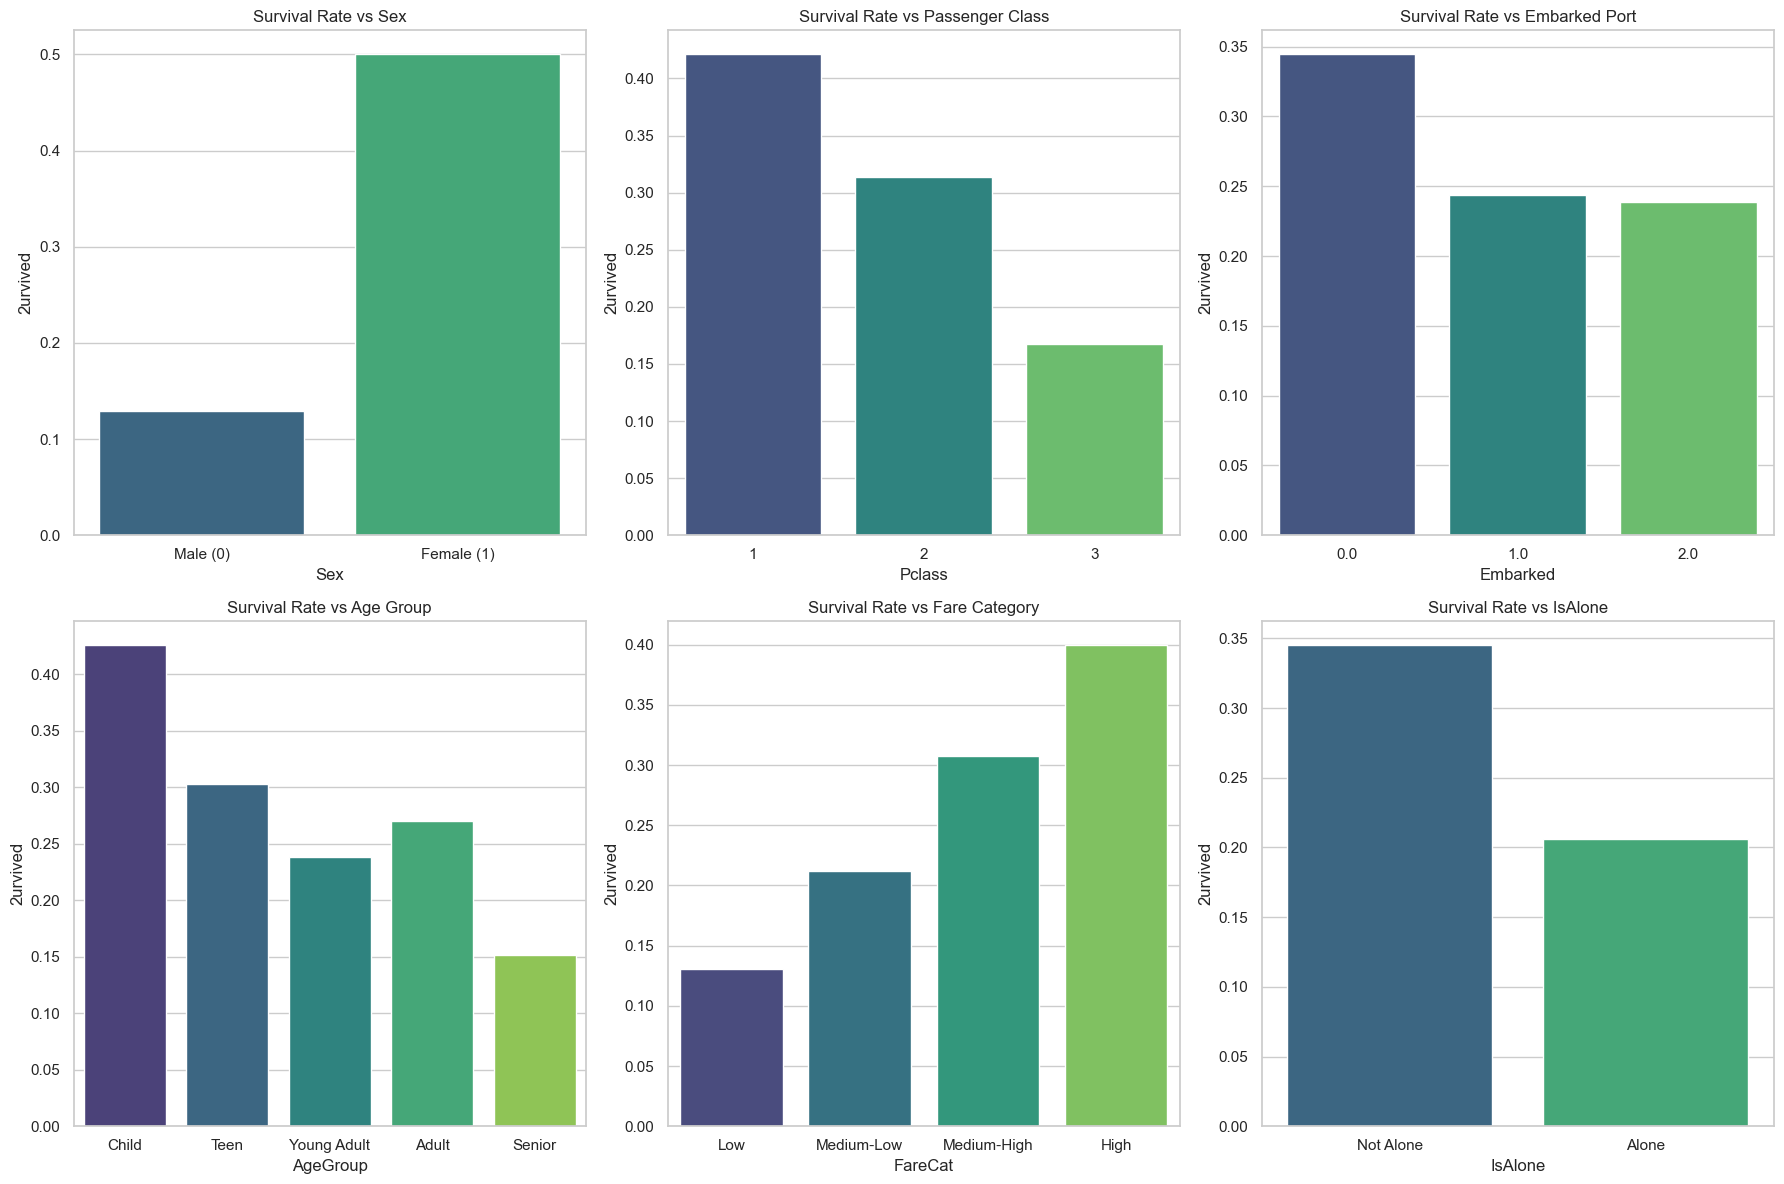

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Survival vs Gender
sns.barplot(x='Sex', y='2urvived', data=df_eda, ax=axes[0, 0], ci=None, palette='viridis')
axes[0, 0].set_title('Survival Rate vs Sex')
axes[0, 0].set_xticklabels(['Male (0)', 'Female (1)'])

# 2. Survival vs Passenger Class
sns.barplot(x='Pclass', y='2urvived', data=df_eda, ax=axes[0, 1], ci=None, palette='viridis')
axes[0, 1].set_title('Survival Rate vs Passenger Class')

# 3. Survival vs Embarked
sns.barplot(x='Embarked', y='2urvived', data=df_eda, ax=axes[0, 2], ci=None, palette='viridis')
axes[0, 2].set_title('Survival Rate vs Embarked Port')

# 4. Survival vs Age Group
df_eda['AgeGroup'] = pd.cut(df_eda['Age'], bins=[0, 12, 18, 35, 60, 80], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
sns.barplot(x='AgeGroup', y='2urvived', data=df_eda, ax=axes[1, 0], ci=None, palette='viridis')
axes[1, 0].set_title('Survival Rate vs Age Group')

# 5. Survival vs Fare Category
df_eda['FareCat'] = pd.qcut(df_eda['Fare'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
sns.barplot(x='FareCat', y='2urvived', data=df_eda, ax=axes[1, 1], ci=None, palette='viridis')
axes[1, 1].set_title('Survival Rate vs Fare Category')

# 6. Survival vs IsAlone
sns.barplot(x='IsAlone', y='2urvived', data=df_eda_feat, ax=axes[1, 2], ci=None, palette='viridis')
axes[1, 2].set_title('Survival Rate vs IsAlone')
axes[1, 2].set_xticklabels(['Not Alone', 'Alone'])

plt.tight_layout()
plt.show()

### Key Observations from EDA:
1. **Sex**: Females (Sex=1) have a significantly higher survival rate (~74%) compared to males (~19%).
2. **Pclass**: First-class passengers had the highest survival rates (~63%), followed by second-class (~47%), and third-class (~24%).
3. **Fare**: Higher fares correlate strongly with higher survival rates.
4. **Age**: Children had a higher survival rate compared to other age brackets.
5. **Embarked**: Port `0.0` (Cherbourg) shows a higher survival rate compared to other ports.
6. **IsAlone**: Traveling with family (Not Alone) increases the likelihood of survival.

## 4. Preprocessing Strategy & Verification

Now we apply the preprocessing utilities to prepare the dataset for train-test split (Phase 1 endpoint).

In [11]:
# Load clean features and target
df_raw = load_dataset(dataset_path)
df_cleaned = clean_dataset(df_raw, drop_zeros=True)
df_features = engineer_features(df_cleaned)

# Split into X and y
X, y = split_features_target(df_features, target_col='2urvived')

# Detect types
types = detect_feature_types(X)
print("Detected Feature Types:", types)

# One-Hot encode categorical variables ('Pclass', 'Embarked')
# Note: Sex is already binary-encoded as 0/1 in the dataset, so we only need to encode Pclass and Embarked.
X_encoded = encode_features(X, cat_cols=['Pclass', 'Embarked'])

# Prepare Train-Test Split
X_train, X_test, y_train, y_test = prepare_train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"\nPreprocessed Train shapes: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Preprocessed Test shapes: X_test: {X_test.shape}, y_test: {y_test.shape}")
print("Final Columns after One-Hot Encoding:", X_train.columns.tolist())

Detected Feature Types: {'numerical': ['Age', 'Fare'], 'categorical': ['sibsp', 'Parch', 'Pclass', 'Embarked', 'FamilySize'], 'binary': ['Sex', 'IsAlone']}

Preprocessed Train shapes: X_train: (1047, 11), y_train: (1047,)
Preprocessed Test shapes: X_test: (262, 11), y_test: (262,)
Final Columns after One-Hot Encoding: ['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'FamilySize', 'IsAlone', 'Pclass_2', 'Pclass_3', 'Embarked_1.0', 'Embarked_2.0']


### Scaling Decision Justification:
Decision Tree classifiers partition the feature space using orthogonal decision boundaries (e.g., $X_j > t$). Since the splits are monotonic and evaluated feature-by-feature, the scale of one feature does not influence the splits of other features. Thus, **feature scaling is not required** for Decision Trees. We will not scale the features to preserve model interpretability.